Connected to base (Python 3.12.7)

### 1. Analysis which are not branchpoint specific
1. Show coverage for all unlabelled cells
2. Day2 and Day4 Differentiated Cells with its Cell Type in Prediction Set
3. Distribution of size of prediction set
4. Use prediction set of day4 undiff to validate

In [1]:
import sys
sys.path.append('/Users/zhaoyimin/Desktop/larry gpu speed up')
import os
import scanpy as sc
from utils import compute_nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
import pickle
os.chdir('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance')
data = sc.read_h5ad('./data_complete_results_clone.h5ad')

In [2]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

### Plot mellon density

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


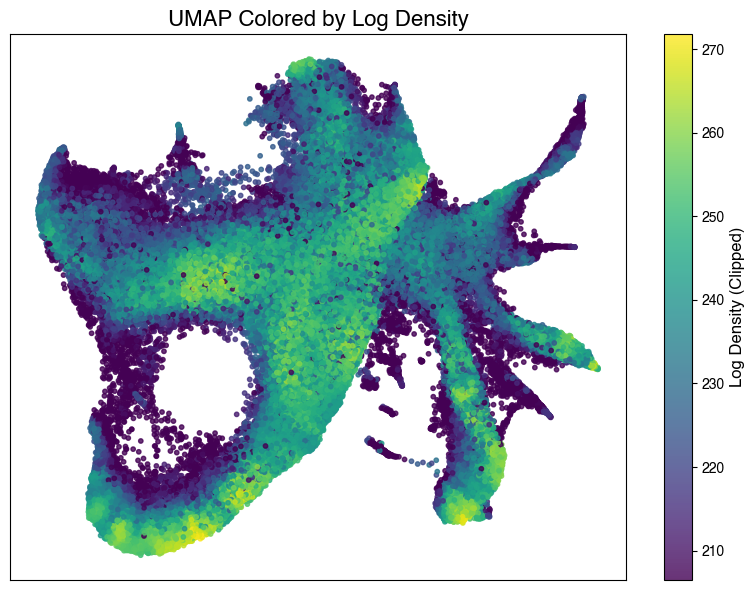

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0], 
    'umap2': data.obsm['X_umap'][:, 1], 
    'Labels': data.obs['mellon_log_density_clipped'].to_list()
})


# Create scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['umap1'], df['umap2'], 
    c=df['Labels'], 
    cmap='viridis',  # or 'plasma', 'coolwarm', etc.
    s=10,            # marker size
    alpha=0.8
)

plt.xticks([])
plt.yticks([])

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Log Density (Clipped)', fontsize=12)

# Aesthetics
plt.xlabel('')
plt.ylabel('')
plt.title('UMAP Colored by Log Density', fontsize=16)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('./vector plot/Figure3_Larry_mellondensity.pdf')

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

############################################
# 0. Make Illustrator text editable
############################################
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

############################################
# 1. Build dataframe from AnnData
############################################
df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0],
    'umap2': data.obsm['X_umap'][:, 1],
    'density': data.obs['mellon_log_density_clipped'].to_list()
    # if you also have discrete labels for legend, you'd also pull:
    # 'cluster': data.obs['cluster_label_column'].to_list()
})

############################################
# 2. PANEL A: main UMAP scatter (rasterized)
############################################
fig_scatter, ax_scatter = plt.subplots(figsize=(4, 4))  # square panel

sc = ax_scatter.scatter(
    df['umap1'],
    df['umap2'],
    c=df['density'],
    cmap='viridis',
    s=10,
    alpha=0.8,
    rasterized=True  # <--- critical for Illustrator performance
)

ax_scatter.set_xticks([])
ax_scatter.set_yticks([])
ax_scatter.set_xlabel('')
ax_scatter.set_ylabel('')
ax_scatter.set_title('')

fig_scatter.tight_layout()

fig_scatter.savefig(
    './vector plot/Figure3_mellondensity_scatter.pdf',
    dpi=300
)
plt.close(fig_scatter)

############################################
# Grab colormap/norm info from the scatter
############################################
cmap = sc.cmap
norm = sc.norm

############################################
# 3. PANEL B: vertical colorbar ONLY
# MATCH your desired style:
# - tall bar
# - decent thickness
# - ticks along the right
# - rotated label next to bar
# - tight PDF bounds
############################################

# create a separate figure just for the colorbar
# figsize controls absolute physical size in inches in the PDF.
# We'll start with something tall and skinny (but not microscopic).
fig_cb = plt.figure(figsize=(1.4, 4.0))  # width, height in inches

# Manually create an Axes that defines where the bar goes.
# [left, bottom, width, height] are in figure coordinates (0-1).
# We'll make the bar itself fairly thick, like in your "want" image.
cax = fig_cb.add_axes([0.25, 0.05, 0.25, 0.90])
#          left   bottom width height
# You can tweak width (0.25) bigger if you want a fatter bar.
# You can tweak left to move the bar horizontally.

# Build a ScalarMappable so the colorbar knows the colormap and range.
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

# Draw the colorbar
cbar = fig_cb.colorbar(
    mappable,
    cax=cax,
    orientation='vertical'
)

# Tick styling
cbar.ax.tick_params(labelsize=10)

# Put the label rotated vertically, like your target
cbar.set_label(
    'Log Density (Clipped)',
    fontsize=12,
    rotation=90,
    labelpad=15
)

# IMPORTANT:
# We DO NOT call tight_layout() here, because we are manually
# placing cax in figure coordinates.

# Save tightly cropped around content (removes giant white margins)
fig_cb.savefig(
    './vector plot/Figure3_mellondensity_colorbar.pdf',
    bbox_inches='tight'
)

plt.close(fig_cb)

############################################
# 4. PANEL C (optional): discrete legend ONLY
# Only run this if you ALSO want the cell type legend
# like Branchpoint / Mono / DC / Ery.
# If you don't need it, you can ignore this block.
############################################

legend_labels = ['Branchpoint', 'Mono', 'DC', 'Ery']
legend_colors = ['red', 'royalblue', 'orange', 'green']

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=legend_colors[i],
        markeredgecolor='none',
        markersize=8,
        label=legend_labels[i]
    )
    for i in range(len(legend_labels))
]

fig_leg, ax_leg = plt.subplots(figsize=(2, 2))
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_handles,
    loc='center left',
    frameon=False,
    handletextpad=0.5,
    labelspacing=0.8,
    borderpad=0.0
)

for text in leg.get_texts():
    text.set_fontsize(10)

fig_leg.savefig(
    './vector plot/Figure3_celltype_legend.pdf',
    bbox_inches='tight'
)

plt.close(fig_leg)

############################################
# Outputs:
#   Figure3_mellondensity_scatter.pdf
#       - scatter plot only
#       - points rasterized for speed
#       - title text is still editable in Illustrator
#
#   Figure3_mellondensity_colorbar.pdf
#       - tall vertical bar
#       - same style as "what I want"
#       - tightly cropped
#
#   Figure3_celltype_legend.pdf
#       - optional discrete legend with colored dots
#       - vector, small, easy to place
############################################



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


#### 1.1 show coverage for all unlabelled cells

In [4]:
# Load data
with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)
#data.obs = data.obs.rename(columns={'cover_Mono': 'cover_Monocyte'})
#data.obs = data.obs.rename(columns={'cover_Ccr7': 'cover_Ccr7_DC'})

#get pseudo time ranks
terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0' ) & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
print('There are {} day 6 terminal state cells'.format(len(day6_terminal_barcode)))
pseudo_time_ranks = np.argsort(data.obs['palantir_pseudotime'][cells2recruit_barcode].values)[::-1] #pseudo_time_ranks contains indices that sort palantir_pseudotime in descending order.

#get recruitment size
recruitment_size = conformal_result['recruitment_size']

There are 36096 day 6 terminal state cells


In [3]:
# Load data
with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)
#data.obs = data.obs.rename(columns={'cover_Mono': 'cover_Monocyte'})
#data.obs = data.obs.rename(columns={'cover_Ccr7': 'cover_Ccr7_DC'})

#get pseudo time ranks
terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0' ) & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
print('There are {} day 6 terminal state cells'.format(len(day6_terminal_barcode)))
pseudo_time_ranks = np.argsort(data.obs['palantir_pseudotime'][cells2recruit_barcode].values)[::-1] #pseudo_time_ranks contains indices that sort palantir_pseudotime in descending order.

#get recruitment size
recruitment_size = conformal_result['recruitment_size']

#1 plot size of prediction for all test points
data.obs['size_pred_set'] = conformal_result['size']['prediction_set_size']

# Create DataFrame
df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0], 
    'umap2': data.obsm['X_umap'][:, 1], 
    'Labels': data.obs['state_info'].to_list(),
    'pred_set': data.obs['size_pred_set'].tolist()
})

# Define color mapping for pred_set
def get_pred_set_color(pred_set_value):
    if pred_set_value == 1:
        return np.array([0.93126922, 0.82019218, 0.7971481, 1.])
    elif pred_set_value == 2:
        return np.array([0.78404409, 0.52926605, 0.62005689, 1.])
    elif pred_set_value in [3, 4, 5]:
        return np.array([0.5151069, 0.29801048, 0.49050619, 1.])
    elif pred_set_value in [6, 7, 8]:
        return np.array([0.17508656, 0.11840023, 0.24215989, 1])
    else:
        return np.array([0.5, 0.5, 0.5, 1.])  # Default gray for other values

# Apply color mapping
df['pred_set_color'] = df['pred_set'].apply(get_pred_set_color)

# Separate the data
df1 = df[df['Labels'] == 'undiff']  # Undifferentiated cells
df2 = df[df['Labels'] != 'undiff']  # Differentiated cells

palette = sns.color_palette("tab10", n_colors=df2['Labels'].nunique())
labels_unique = df2['Labels'].unique()
label_to_color = {
    label: palette[i] for i, label in enumerate(labels_unique)
}
import json
with open("/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/color_palette_tab10.json", "w") as f:
    json.dump(label_to_color, f)

There are 36096 day 6 terminal state cells


There are 36096 day 6 terminal state cells


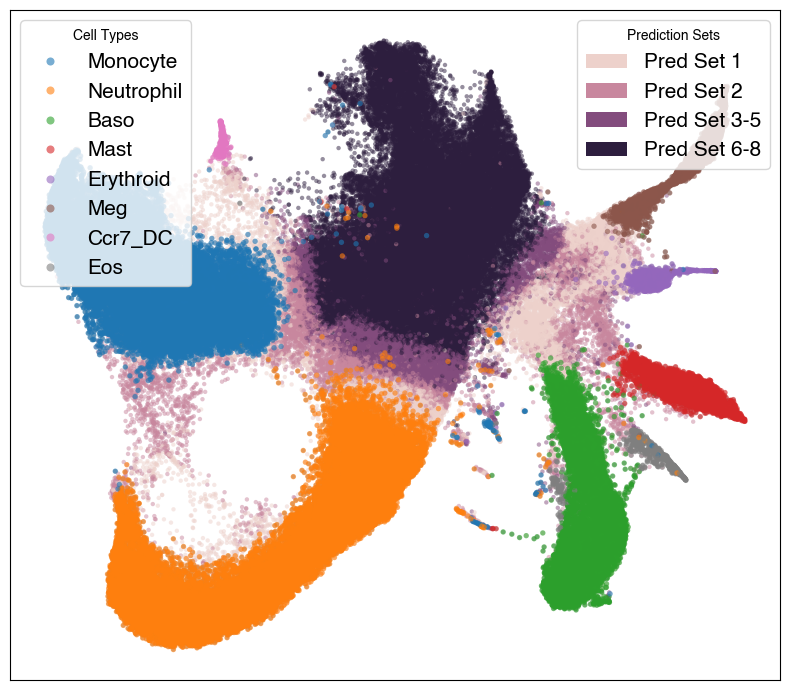

In [ ]:
# Load data
with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)
#data.obs = data.obs.rename(columns={'cover_Mono': 'cover_Monocyte'})
#data.obs = data.obs.rename(columns={'cover_Ccr7': 'cover_Ccr7_DC'})

#get pseudo time ranks
terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0' ) & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
print('There are {} day 6 terminal state cells'.format(len(day6_terminal_barcode)))
pseudo_time_ranks = np.argsort(data.obs['palantir_pseudotime'][cells2recruit_barcode].values)[::-1] #pseudo_time_ranks contains indices that sort palantir_pseudotime in descending order.

#get recruitment size
recruitment_size = conformal_result['recruitment_size']

#1 plot size of prediction for all test points
data.obs['size_pred_set'] = conformal_result['size']['prediction_set_size']

# Create DataFrame
df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0], 
    'umap2': data.obsm['X_umap'][:, 1], 
    'Labels': data.obs['state_info'].to_list(),
    'pred_set': data.obs['size_pred_set'].tolist()
})

# Define color mapping for pred_set
def get_pred_set_color(pred_set_value):
    if pred_set_value == 1:
        return np.array([0.93126922, 0.82019218, 0.7971481, 1.])
    elif pred_set_value == 2:
        return np.array([0.78404409, 0.52926605, 0.62005689, 1.])
    elif pred_set_value in [3, 4, 5]:
        return np.array([0.5151069, 0.29801048, 0.49050619, 1.])
    elif pred_set_value in [6, 7, 8]:
        return np.array([0.17508656, 0.11840023, 0.24215989, 1])
    else:
        return np.array([0.5, 0.5, 0.5, 1.])  # Default gray for other values

# Apply color mapping
df['pred_set_color'] = df['pred_set'].apply(get_pred_set_color)

# Separate the data
df1 = df[df['Labels'] == 'undiff']  # Undifferentiated cells
df2 = df[df['Labels'] != 'undiff']  # Differentiated cells

# Set figure size
plt.figure(figsize=(8, 7))

# First layer: Add prediction set colors
colors_array = np.array([color for color in df['pred_set_color']])
plt.scatter(df['umap1'], df['umap2'], 
           c=colors_array, s=10, alpha=0.5, linewidth=0)

# Second layer: Plot differentiated cells colored by Labels
palette = sns.color_palette("tab10", n_colors=df2['Labels'].nunique())
sns.scatterplot(
    x='umap1', y='umap2', data=df2,
    hue='Labels', palette='tab10', s=15, linewidth=0, alpha=0.6, legend='brief'
)

"""
labels_unique = df2['Labels'].unique()
label_to_color = {
    label: palette[i] for i, label in enumerate(labels_unique)
}
import json
with open("color_palette_tab10.json", "w") as f:
    json.dump(label_to_color, f)
"""

plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

# Save the first legend (cell types) before creating the second one
first_legend = plt.legend(loc='upper left', fontsize=15, markerscale=1.5, title='Cell Types')

# Add a custom legend for prediction sets
pred_legend_elements = [
    Patch(facecolor=[0.93126922, 0.82019218, 0.7971481, 1.], label='Pred Set 1'),
    Patch(facecolor=[0.78404409, 0.52926605, 0.62005689, 1.], label='Pred Set 2'),
    Patch(facecolor=[0.5151069, 0.29801048, 0.49050619, 1.], label='Pred Set 3-5'),
    Patch(facecolor=[0.17508656, 0.11840023, 0.24215989, 1], label='Pred Set 6-8')
]

# Create the second legend for prediction sets
pred_legend = plt.legend(handles=pred_legend_elements, loc='upper right', 
                        fontsize=15, title='Prediction Sets')

# Add the first legend back to the plot
plt.gca().add_artist(first_legend)
plt.tight_layout()

#plt.savefig('./vector plot/Figure3_Larry_celltype_prediction_set_size_umap.svg', dpi=300, bbox_inches='tight')
#plt.savefig('./vector plot/Figure3_Larry_celltype_prediction_set_size_umap.pdf')

In [22]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

############################################
# 0. Illustrator-friendly text
############################################
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

############################################
# 1. Load / prep your data (your logic)
############################################

with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)

terminal_state_celltype = [
    'Monocyte', 'Neutrophil', 'Baso', 'Mast',
    'Erythroid', 'Meg', 'Eos', 'Ccr7_DC'
]

day6_terminal_barcode = data[
    (data.obs['Time_Point'] == '6.0') &
    (data.obs['state_info'].isin(terminal_state_celltype))
].obs_names.tolist()

cells2recruit_barcode = data.obs_names[
    ~data.obs_names.isin(day6_terminal_barcode)
].tolist()

print('There are {} day 6 terminal state cells'.format(len(day6_terminal_barcode)))

pseudo_time_ranks = np.argsort(
    data.obs['palantir_pseudotime'][cells2recruit_barcode].values
)[::-1]

data.obs['size_pred_set'] = conformal_result['size']['prediction_set_size']

############################################
# 2. Build dataframe for plotting
############################################
df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0],
    'umap2': data.obsm['X_umap'][:, 1],
    'Labels': data.obs['state_info'].to_list(),          # cell types
    'pred_set': data.obs['size_pred_set'].tolist()       # prediction set size
})

# color mapping for pred_set layer (background shading)
def get_pred_set_color(pred_set_value):
    if pred_set_value == 1:
        return np.array([0.93126922, 0.82019218, 0.7971481, 1.])
    elif pred_set_value == 2:
        return np.array([0.78404409, 0.52926605, 0.62005689, 1.])
    elif pred_set_value in [3, 4, 5]:
        return np.array([0.5151069, 0.29801048, 0.49050619, 1.])
    elif pred_set_value in [6, 7, 8]:
        return np.array([0.17508656, 0.11840023, 0.24215989, 1])
    else:
        return np.array([0.5, 0.5, 0.5, 1.])  # fallback gray

df['pred_set_color'] = df['pred_set'].apply(get_pred_set_color)

# differentiated cells only (you used df2 = df[df['Labels'] != 'undiff'])
df2 = df[df['Labels'] != 'undiff'].copy()

############################################
# 3. Reproduce EXACT seaborn color mapping deterministically
#
# seaborn internally does:
#   unique_levels_in_order = pandas.unique(hue_series)
#   palette_colors = sns.color_palette("tab10", n_colors=len(unique_levels_in_order))
#   mapping = {level: color[i]}
#
# We will do exactly that.
############################################

# this preserves the "first appearance" order in df2['Labels'],
# which is what seaborn uses for hue order / legend order
celltype_order = pd.unique(df2['Labels'])

palette_colors = sns.color_palette("tab10", n_colors=len(celltype_order))

# build a dict: label -> RGBA
label_to_color = {
    ct: palette_colors[i]
    for i, ct in enumerate(celltype_order)
}
# Now label_to_color['Monocyte'] etc. matches seaborn's assignment.

############################################
# 4. PANEL MAIN:
#    - background layer = pred_set_color
#    - foreground layer = cell types by label_to_color
#    - rasterized=True to keep Illustrator fast
#    - NO legends drawn
############################################

fig_main, ax_main = plt.subplots(figsize=(8, 7))

# layer 1: pred_set shading
ax_main.scatter(
    df['umap1'], df['umap2'],
    c=np.vstack(df['pred_set_color'].values),
    s=10,
    alpha=0.5,
    linewidth=0,
    rasterized=True
)

# layer 2: each cell type cluster with its assigned color
for ct in celltype_order:
    sub = df2[df2['Labels'] == ct]
    if len(sub) == 0:
        continue
    ax_main.scatter(
        sub['umap1'], sub['umap2'],
        c=[label_to_color[ct]],
        s=15,
        alpha=0.6,
        linewidth=0,
        rasterized=True
    )

# match your aesthetic cleanup
ax_main.set_title('')
ax_main.set_xlabel('')
ax_main.set_ylabel('')
ax_main.set_xticks([])
ax_main.set_yticks([])

fig_main.tight_layout()

fig_main.savefig(
    './vector plot/Figure3_umap_main.pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.close(fig_main)

############################################
# 5. PANEL LEGEND A: Cell Types legend only
#    - must match EXACT same colors and order
#    - draw a nice white box with black edge like your screenshot
############################################

celltype_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=label_to_color[ct],
        markeredgecolor='none',
        markersize=8,
        label=ct
    )
    for ct in celltype_order
]

fig_legend_a, ax_legend_a = plt.subplots(figsize=(3, 3))
ax_legend_a.axis('off')

leg_a = ax_legend_a.legend(
    handles=celltype_handles,
    loc='center left',
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='black',
    title='Cell Types',
    fontsize=12,
    title_fontsize=12,
    labelspacing=0.6,
    handletextpad=0.5,
    borderpad=0.5
)

fig_legend_a.savefig(
    './vector plot/Figure3_umap_legend_celltypes.pdf',
    bbox_inches='tight'
)
plt.close(fig_legend_a)

############################################
# 6. PANEL LEGEND B: Prediction Sets legend only
#    - exactly your RGBA colors and labels
#    - same white rounded-looking box style (frameon=True)
############################################

pred_legend_elements = [
    Patch(facecolor=[0.93126922, 0.82019218, 0.7971481, 1.],  label='Pred Set 1'),
    Patch(facecolor=[0.78404409, 0.52926605, 0.62005689, 1.], label='Pred Set 2'),
    Patch(facecolor=[0.5151069, 0.29801048, 0.49050619, 1.],  label='Pred Set 3-5'),
    Patch(facecolor=[0.17508656, 0.11840023, 0.24215989, 1],  label='Pred Set 6-8')
]

fig_legend_b, ax_legend_b = plt.subplots(figsize=(3, 2.5))
ax_legend_b.axis('off')

leg_b = ax_legend_b.legend(
    handles=pred_legend_elements,
    loc='center left',
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='black',
    title='Prediction Sets',
    fontsize=12,
    title_fontsize=12,
    labelspacing=0.6,
    handletextpad=0.5,
    borderpad=0.5
)

fig_legend_b.savefig(
    './vector plot/Figure3_umap_legend_predsets.pdf',
    bbox_inches='tight'
)
plt.close(fig_legend_b)

############################################
# Output summary:
#
# ./vector plot/Figure3_umap_main.pdf
#   - Uses *exact* same label→color mapping seaborn would use (tab10, first-seen order)
#   - pred_set "wash" underneath
#   - rasterized points so Illustrator is smooth
#   - no legends
#
# ./vector plot/Figure3_umap_legend_celltypes.pdf
#   - Cell Types legend, white box + border, vector text
#   - Colors match main exactly now
#
# ./vector plot/Figure3_umap_legend_predsets.pdf
#   - Prediction Sets legend, same style box, vector text
#
# You can now lay out main panel + legends in Illustrator
# and you're guaranteed that Monocyte/Neutrophil/etc. colors match.
############################################



There are 36096 day 6 terminal state cells


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In [21]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------
# Matplotlib global settings
# ---------------------------

# Use Helvetica (falls back to Arial/DejaVu Sans if missing)
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42   # keep text editable in Illustrator
mpl.rcParams['ps.fonttype'] = 42

# ---------------------------
# Load data
# ---------------------------

with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)

# terminal states
terminal_state_celltype = [
    'Monocyte', 'Neutrophil', 'Baso', 'Mast',
    'Erythroid', 'Meg', 'Eos', 'Ccr7_DC'
]

day6_terminal_barcode = data[
    (data.obs['Time_Point'] == '6.0') &
    (data.obs['state_info'].isin(terminal_state_celltype))
].obs_names.tolist()

cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
print('There are {} day 6 terminal state cells'.format(len(day6_terminal_barcode)))

pseudo_time_ranks = np.argsort(
    data.obs['palantir_pseudotime'][cells2recruit_barcode].values
)[::-1]

# prediction set size (already computed in conformal_result)
data.obs['size_pred_set'] = conformal_result['size']['prediction_set_size']

# ---------------------------
# Build plotting DataFrame
# ---------------------------

df = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0],
    'umap2': data.obsm['X_umap'][:, 1],
    'Labels': data.obs['state_info'].to_list(),
    'pred_set': data.obs['size_pred_set'].tolist()
})

def get_pred_set_color(pred_set_value):
    if pred_set_value == 1:
        return np.array([0.93126922, 0.82019218, 0.7971481, 1.])
    elif pred_set_value == 2:
        return np.array([0.78404409, 0.52926605, 0.62005689, 1.])
    elif pred_set_value in [3, 4, 5]:
        return np.array([0.5151069, 0.29801048, 0.49050619, 1.])
    elif pred_set_value in [6, 7, 8]:
        return np.array([0.17508656, 0.11840023, 0.24215989, 1])
    else:
        return np.array([0.5, 0.5, 0.5, 1.])  # fallback gray

df['pred_set_color'] = df['pred_set'].apply(get_pred_set_color)

# split by undiff / diff (not strictly needed for plotting but we keep it)
df1 = df[df['Labels'] == 'undiff']
df2 = df[df['Labels'] != 'undiff']

# ---------------------------
# Plot
# ---------------------------

fig, ax = plt.subplots(figsize=(8.5, 6))

# layer 1: prediction set background colors
colors_array = np.array([color for color in df['pred_set_color']])
ax.scatter(
    df['umap1'], df['umap2'],
    c=colors_array,
    s=10,
    alpha=0.5,
    linewidth=0
)

# layer 2: differentiated cells with cell type colors
palette = sns.color_palette("tab10", n_colors=df2['Labels'].nunique())
sns.scatterplot(
    x='umap1', y='umap2', data=df2,
    hue='Labels', palette='tab10',
    s=15, linewidth=0, alpha=0.6,
    legend='brief', ax=ax
)

ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# ---------------------------
# Legends
# ---------------------------

# first legend: cell types (this is the one created by seaborn above)
first_legend = ax.legend(
    loc='upper left',          # anchor mode
    bbox_to_anchor=(1.02, 1),  # (x, y) in axes fraction outside the plot
    fontsize=14,
    markerscale=1.5,
    title='Cell Types',
    frameon=True
)

# second legend: prediction set size
pred_legend_elements = [
    Patch(facecolor=[0.93126922, 0.82019218, 0.7971481, 1.], label='Pred Set 1'),
    Patch(facecolor=[0.78404409, 0.52926605, 0.62005689, 1.], label='Pred Set 2'),
    Patch(facecolor=[0.5151069, 0.29801048, 0.49050619, 1.], label='Pred Set 3–5'),
    Patch(facecolor=[0.17508656, 0.11840023, 0.24215989, 1], label='Pred Set 6–8')
]

pred_legend = ax.legend(
    handles=pred_legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.55),  # same x as first legend, lower y
    fontsize=14,
    title='Prediction Sets',
    frameon=True
)

# we have to manually add both legends back to the axes
ax.add_artist(first_legend)
ax.add_artist(pred_legend)

# ---------------------------
# Layout and save
# ---------------------------

# leave some room on the right (0.82 can be tweaked if legends get cut)
plt.tight_layout(rect=[0, 0, 0.8, 1])

plt.savefig(
    './vector plot/Figure3_Larry_celltype_prediction_set_size_umap.pdf'
)
plt.close(fig)


There are 36096 day 6 terminal state cells


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


#### 1.2 Day2 and Day4 Differentiated Cells with its Cell Type in Prediction Set

Type of conformal_result['prediction_set']: <class 'pandas.core.frame.DataFrame'>
First few entries:                           prediction_set
LK_d4_2:GTAAGCCG-CAACGTGG          {Meg}
LK_d4_2:ACAAAGAT-TCGGTTCG          {Meg}
d4_2_2:CCGATACG-AGCAGAAC          {Mast}
d4_1_1:TAACTTCT-TAGTGTTT          {Mast}
d4_1_2:CGTGTGTT-AGCGAAGT          {Mast}
Shape of conformal_pred_set: (93833, 1)
8455
7789
3434
619
253
729
204
157
    Cell Type  All Covered
0    Monocyte     0.999527
1  Neutrophil     0.999358
2        Baso     1.000000
3        Mast     0.998384
4   Erythroid     0.988142
5         Meg     1.000000
6         Eos     1.000000
7     Ccr7_DC     0.993631


/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_16450/452613333.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


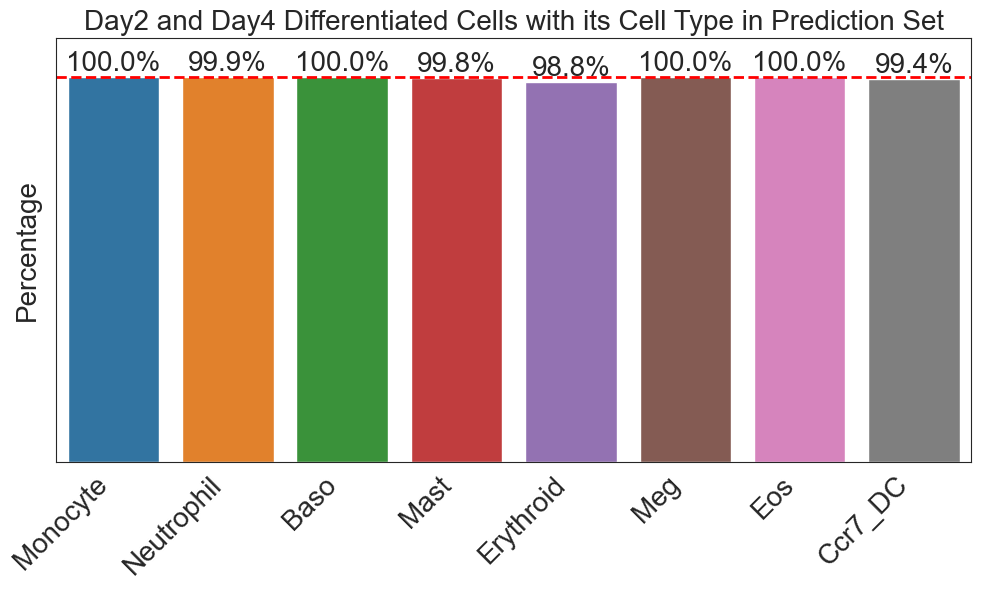

In [5]:
day24_differentiated = data[(data.obs['Time_Point'].isin(['4.0', '2.0'])) & (data.obs['state_info'] != 'undiff')]
day24_results = {}
cell_types = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']

# Create mapping from full names to prediction set names
type_mapping = {
    'Monocyte': 'Monocyte',
    'Neutrophil': 'Neutrophil', 
    'Baso': 'Baso',
    'Mast': 'Mast',
    'Erythroid': 'Erythroid',
    'Meg': 'Meg',
    'Eos': 'Eos',
    'Ccr7_DC': 'Ccr7_DC'
}

# Check the structure of conformal_result['prediction_set']
print("Type of conformal_result['prediction_set']:", type(conformal_result['prediction_set']))
print("First few entries:", conformal_result['prediction_set'][:5] if hasattr(conformal_result['prediction_set'], '__getitem__') else conformal_result['prediction_set'])

# Handle different possible structures
if isinstance(conformal_result['prediction_set'], pd.DataFrame):
    conformal_pred_set = conformal_result['prediction_set']
elif isinstance(conformal_result['prediction_set'], pd.Series):
    conformal_pred_set = conformal_result['prediction_set'].to_frame(name='prediction_set')
elif isinstance(conformal_result['prediction_set'], (list, np.ndarray)):
    # If it's a list/array, we need to get the correct indices
    # Get the cells that were used for prediction (cells2recruit_barcode)
    terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
    day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0') & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
    cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
    
    conformal_pred_set = pd.DataFrame({
        'prediction_set': conformal_result['prediction_set']
    }, index=cells2recruit_barcode)
else:
    raise ValueError(f"Unexpected type for prediction_set: {type(conformal_result['prediction_set'])}")

print("Shape of conformal_pred_set:", conformal_pred_set.shape)

# Iterate through each cell type
for cell_type in cell_types:
    subset = day24_differentiated[day24_differentiated.obs['state_info'] == cell_type]
    if subset.n_obs > 0:
        # Check if the cell type appears in prediction set using the mapped name
        pred_name = type_mapping[cell_type]
        covered_cells = []
        
        for barcode in subset.obs_names:
            if barcode in conformal_pred_set.index:
                pred_set = conformal_pred_set.loc[barcode, 'prediction_set']
                if isinstance(pred_set, set) and pred_name in pred_set:
                    covered_cells.append(True)
                else:
                    covered_cells.append(False)
            else:
                covered_cells.append(False)
        
        num_covered = sum(covered_cells)
        day24_results[cell_type] = num_covered / subset.n_obs
        print(subset.n_obs)
    else:
        day24_results[cell_type] = 'No cells of this type'

# Convert to DataFrame for display
detailed_df = pd.DataFrame(list(day24_results.items()), columns=['Cell Type', 'All Covered'])

# Display the result
print(detailed_df)

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'All Covered' is numeric
detailed_df['All Covered'] = pd.to_numeric(detailed_df['All Covered'], errors='coerce')

# Sort for better layout
detailed_df_sorted = detailed_df.sort_values(by='All Covered', ascending=False)

# Define palette (you may need to adjust this based on your color scheme)
palette = 'tab10'

# Set figure size
plt.figure(figsize=(10, 6))
sns.set_style("white") 
# Create barplot with Seaborn
ax = sns.barplot(
    x='Cell Type',
    y='All Covered',
    data=detailed_df,
    palette=palette
)

# Add horizontal dashed red line at y = 1
plt.axhline(y=1, color='red', linestyle='--', linewidth=2)
# Add percentage annotations
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=20)
    
# Annotate the dashed line
#plt.text(x=len(detailed_df) - 0.5,  # near the end of the x-axisy=1.05,s="Percentage = 100",color='red',fontsize=16,ha='right')

# Final plot tweaks
plt.ylim(0, 1.1)
plt.title("Day2 and Day4 Differentiated Cells with its Cell Type in Prediction Set", fontsize=20)
plt.ylabel("Percentage", fontsize = 20)
plt.xlabel("")
ax.set_yticklabels([]) 
plt.xticks(rotation=45, ha='right', fontsize = 20)
plt.tight_layout()
plt.savefig('./vector plot/Figure3_Larry_porp.pdf')

In [8]:
conformal_result['prediction_set']

,prediction_set
LK_d4_2:GTAAGCCG-CAACGTGG,{Meg}
LK_d4_2:ACAAAGAT-TCGGTTCG,{Meg}
d4_2_2:CCGATACG-AGCAGAAC,{Mast}
d4_1_1:TAACTTCT-TAGTGTTT,{Mast}
d4_1_2:CGTGTGTT-AGCGAAGT,{Mast}
...,...
LSK_d2_3:ACTACCCG-CATACATT,"{Eos, Erythroid, Monocyte, Ccr7_DC, Neutrophil..."
LSK_d2_1:AGCACGTA-CGGAATTT,"{Eos, Erythroid, Monocyte, Ccr7_DC, Neutrophil..."
LSK_d2_1:CGAAACTC-GATTTACC,"{Eos, Erythroid, Monocyte, Ccr7_DC, Neutrophil..."
LSK_d2_3:TATCTGTC-GGAAACAG,"{Eos, Erythroid, Monocyte, Ccr7_DC, Neutrophil..."


#### 1.3. distribution of size of prediction set

0.9619685767097966


/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_57169/2874735451.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_df, x='Size', y='log10 counts', palette='muted')


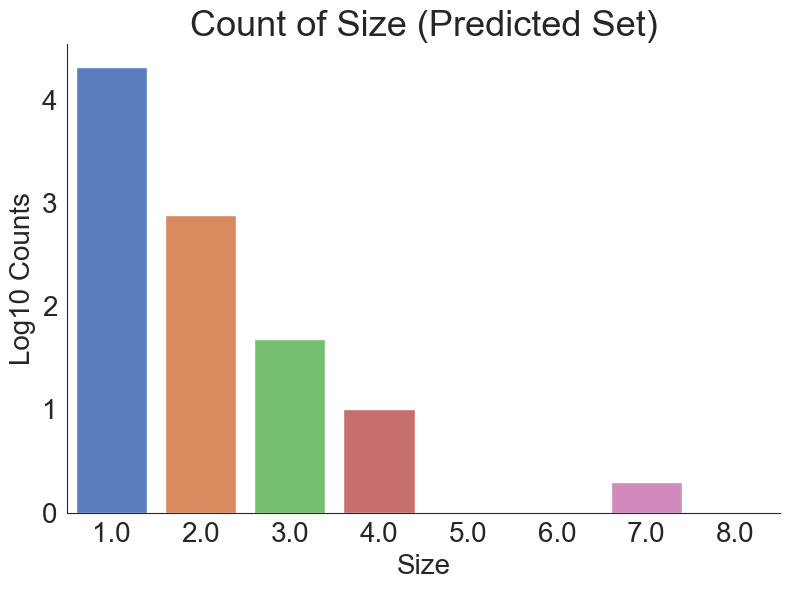

In [16]:
day24_differentiated.obs['size_pred_set'].tolist()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts
size_counts = day24_differentiated.obs['size_pred_set'].value_counts().sort_index()

#proportion of size = 1
proportion = size_counts.iloc[0]/ size_counts.sum()
print(proportion)


# Convert to DataFrame for seaborn
size_df = size_counts.reset_index()
size_df.columns = ['Size', 'Count']
size_df['log10 counts'] = np.log10(size_df['Count'])

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=size_df, x='Size', y='log10 counts', palette='muted')

# Style
plt.title("Count of Size (Predicted Set)", fontsize=26)
plt.xlabel("Size", fontsize=20)
plt.ylabel("Log10 Counts", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
sns.despine()
plt.grid(False)
plt.tight_layout()
#plt.savefig('./vector plot/Figure3_Larry_barplot_power.pdf')


#### 1.4. Use prediction set of day4 undiff to validate
For a clone with undifferentiated cells at day 4, if that clone has both Erythroid and Megakaryocyte cells at day 6, then at least one of “Ery” and “Meg” should appear in the predicted cell type set for its day 4 undifferentiated cells. We could do this analysis per clone. 

In [30]:
import pandas as pd

# ✅ Allowed types and mapping from state_info to prediction set names
allowed_types = {
    'Baso': 'Baso',
    'Ccr7_DC': 'Ccr7', 
    'Eos': 'Eos',
    'Erythroid': 'Erythroid',
    'Mast': 'Mast',
    'Meg': 'Meg',
    'Monocyte': 'Monocyte',
    'Neutrophil': 'Neutrophil'
}

# ✅ Extract needed columns (without cover columns since they don't exist)
cols = ['clone_id', 'Time_Point', 'state_info']
df = data.obs[cols].copy()

# ✅ Define flags
df['is_day4_undiff'] = (df['Time_Point'] == '4.0') & (df['state_info'] == 'undiff')
df['is_day6_diff'] = (df['Time_Point'] == '6.0') & (df['state_info'].isin(allowed_types.keys()))

# ✅ Identify candidate clones
grouped = df.groupby('clone_id').agg({
    'is_day4_undiff': 'any',
    'is_day6_diff': 'any'
})

candidate_clones = grouped[
    (grouped['is_day4_undiff']) &
    (grouped['is_day6_diff'])
].index.tolist()

print(f"Number of candidate clones: {len(candidate_clones)}")

# ✅ Prepare prediction set data
# Handle different possible structures of conformal_result['prediction_set']
if isinstance(conformal_result['prediction_set'], pd.DataFrame):
    conformal_pred_set = conformal_result['prediction_set']
elif isinstance(conformal_result['prediction_set'], pd.Series):
    conformal_pred_set = conformal_result['prediction_set'].to_frame(name='prediction_set')
elif isinstance(conformal_result['prediction_set'], (list, np.ndarray)):
    # Get the cells that were used for prediction (cells2recruit_barcode)
    terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
    day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0') & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
    cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()
    
    conformal_pred_set = pd.DataFrame({
        'prediction_set': conformal_result['prediction_set']
    }, index=cells2recruit_barcode)
else:
    raise ValueError(f"Unexpected type for prediction_set: {type(conformal_result['prediction_set'])}")

import numpy as np

# 1️⃣ For each candidate clone, get its day6 types
clone_day6_types = {}
for cid in candidate_clones:
    day6_types = set(
        df.loc[
            (df['clone_id'] == cid) & (df['is_day6_diff']),
            'state_info'
        ].unique()
    )
    clone_day6_types[cid] = day6_types

# 2️⃣ Filter all day4 undiff cells of candidate clones
day4_cells = df[
    df['is_day4_undiff'] & df['clone_id'].isin(candidate_clones)
].copy()

print(f"Number of candidate day4 undiff cells: {len(day4_cells)}")

# 3️⃣ For each cell: check if its prediction set covers at least one of its clone's actual day6 types
cell_pass = []

for idx, row in day4_cells.iterrows():
    cid = row['clone_id']
    day6_types = clone_day6_types[cid]
    
    # Check if this cell has a prediction set
    passes = False
    if idx in conformal_pred_set.index:
        pred_set = conformal_pred_set.loc[idx, 'prediction_set']
        if isinstance(pred_set, set):
            # Check if any of the predicted cell types match the clone's actual day6 types
            for day6_type in day6_types:
                pred_name = allowed_types[day6_type]
                if pred_name in pred_set:
                    passes = True
                    break
    
    cell_pass.append(passes)

# 4️⃣ Add result to DataFrame
day4_cells['pass_check'] = cell_pass

# 5️⃣ Compute proportion
print(day4_cells['pass_check'].value_counts())
print(f"Fraction of day4 undiff cells passing: {day4_cells['pass_check'].mean():.2%}")

Number of candidate clones: 1420
Number of candidate day4 undiff cells: 5062
pass_check
True     4811
False     251
Name: count, dtype: int64
Fraction of day4 undiff cells passing: 95.04%


In [ ]:
# Save color-to-cell type mapping
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import pickle

# Get differentiated cells data
df = pd.DataFrame({'Labels': data.obs['state_info'].to_list()})
df2 = df[df['Labels'] != 'undiff'].copy()

# Get unique cell types in order (same as seaborn uses)
celltype_order = pd.unique(df2['Labels'])

# Get tab10 palette colors
palette_colors = sns.color_palette("tab10", n_colors=len(celltype_order))

# Create mapping dictionary
color_mapping = {}
for i, ct in enumerate(celltype_order):
    rgb = palette_colors[i]
    hex_color = mcolors.rgb2hex(rgb)
    color_mapping[ct] = {
        'rgb': rgb,
        'hex': hex_color,
        'rgba': (*rgb, 1.0)
    }

# Display the mapping
print("Cell Type to Color Mapping (tab10 palette):")
print("=" * 60)
for ct, colors in color_mapping.items():
    print(f"{ct:15s} -> HEX: {colors['hex']}")

# Save to CSV
color_df = pd.DataFrame([
    {'Cell_Type': ct, 'R': colors['rgb'][0], 'G': colors['rgb'][1], 
     'B': colors['rgb'][2], 'Hex': colors['hex']}
    for ct, colors in color_mapping.items()
])
color_df.to_csv('./color_celltype_mapping.csv', index=False)

# Save as pickle
with open('./color_celltype_mapping.pkl', 'wb') as f:
    pickle.dump(color_mapping, f)

print(f"\n✓ Saved to color_celltype_mapping.csv and .pkl")